In [1]:
import keras
import unicodedata
from keras import layers
from keras import ops

from keras.layers import Layer, Embedding, Input, Dense, GlobalAveragePooling1D, Dropout, MultiHeadAttention, LayerNormalization 
from keras.models import Model

import numpy as np
import tensorflow as tf

2026-05-06 00:52:02.746507: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Introduction  

The purpose of this project is to learn about transformer architecture, specifically its encoder and decoder components, their function and purpose as well as concepts such as cross-attention.  
This project is done with the guidance of [Deep Learning With Python](https://deeplearningwithpython.io/) By François Chollet and Matthew Watson

# Data Understanding  

The intiial plan for a dataset was the simply use a substantial text collection (such as an ebook) from both languages. However upon learning more about transformer structure this proved to be a unviable approach.  
For the transformer to properly work the dataset instead needs to be in word pairs, where first of the pair is in the source language i.e. the language to be translated and the other one in the target language i.e. the language to translate to.  
Luckily there exists multiple choices for viable datasets even in this format such as transcripts written down in multiple languages or volunteer collection of translated sentences.  
The latter of the options is the chosen approach for this project.  
Dataset sourced from https://tatoeba.org/en/downloads


## Loading Data

In [2]:
text_file = "/home/valvoja/projects/2026-Spring-Neural-Network-Project/dataset-local/Sentence pairs in Finnish-English - 2026-04-30.tsv"

text_pairs = []
with open(text_file, encoding='utf-8') as f:
    for line in f:
        val1, finnish, val2, english = line.strip().split("\t")
        english = "[start] " + english + " [end]"
        text_pairs.append((finnish, english))
        
print(text_pairs[:10])

[('Lue mittarin lukema.', '[start] Read the meter. [end]'), ('Imuroin pölyt lattialta pölynimurilla.', '[start] I sucked up the dust on the floor with a vacuum cleaner. [end]'), ('Kuulin sen suoraan naapuriltani.', '[start] I heard about it at first hand from my neighbor. [end]'), ('Heinäkuun kymmenentenä avaamme Sapporoon sivuliikkeen.', '[start] On July 10, we will open our Sapporo branch. [end]'), ('Elämänkerran kirjoittamisessa on vaikeaa se, että se on puoliksi dokumentointia ja puoliksi taidetta.', '[start] The difficulty with biography is that it is partly record and partly art. [end]'), ('Isäni työskentelee insinöörinä siinä tehtaassa.', '[start] My father works at the factory as an engineer. [end]'), ('Se laulaja oli parhaimmillaan tuon laulun aikaan.', '[start] The singer was at his best in that song. [end]'), ('Tuuli puhalsi sateen suoraan kasvoilleni.', '[start] A gust of wind blew a shower of rain directly into my face. [end]'), ('Hän huomasi soutuveneen kaukaisuudessa.', 

## Normalising Text

In [3]:
def normalize(text):
    """Lowercase and normalize unicode (e.g. accents)."""
    text = text.lower().strip()
    text = unicodedata.normalize("NFC", text)
    return text

text_pairs = [(normalize(fi), normalize(en)) for fi, en in text_pairs]

In [4]:
print("Number of sentence pairs:", len(text_pairs))
print("Example pair:")
print("Finnish:", text_pairs[0][0])
print("English:", text_pairs[0][1])

Number of sentence pairs: 105178
Example pair:
Finnish: lue mittarin lukema.
English: [start] read the meter. [end]


## Preparing Data

### Train, Test and Validation Splits

In [5]:
val_samples = int(0.15 * len(text_pairs))
train_samples = len(text_pairs) - 2 * val_samples
train_pairs = text_pairs[:train_samples]
val_pairs = text_pairs[train_samples : train_samples + val_samples]
test_pairs = text_pairs[train_samples + val_samples :]

In [6]:
batch_size = 32
vocab_size = 10000
sequence_length = 20

## Keras Layers Method Tokenizing

In [7]:
import re
import string

# To keep [start] and [end] from turning into "start" and "end"
strip_chars = string.punctuation
strip_chars = strip_chars.replace("[", "")
strip_chars = strip_chars.replace("]", "")

def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(
        lowercase,
        f"[{re.escape(strip_chars)}]",
        ""
    )

finnish_tokenizer = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize=custom_standardization,
)
english_tokenizer = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length + 1,
    standardize=custom_standardization,
)

train_finnish_texts = [pair[0] for pair in train_pairs]
train_english_texts = [pair[1] for pair in train_pairs]
finnish_tokenizer.adapt(train_finnish_texts)
english_tokenizer.adapt(train_english_texts)

I0000 00:00:1778017926.428013   51927 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5562 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6


In [8]:
print(train_pairs[0])

('lue mittarin lukema.', '[start] read the meter. [end]')


### Remerging Tokenized Texts

In [9]:
def format_dataset(fin, eng):
    eng = english_tokenizer(eng)
    fin = finnish_tokenizer(fin)
    features = {"finnish": fin, "english": eng[:, :-1]}
    labels = eng[:, 1:]
    sample_weights = labels != 0
    return features, labels, sample_weights

def make_dataset(pairs):
    fin_texts, eng_texts = zip(*pairs)
    fin_texts = list(fin_texts)
    eng_texts = list(eng_texts)
    dataset = tf.data.Dataset.from_tensor_slices((fin_texts, eng_texts))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(format_dataset, num_parallel_calls=4)
    return dataset.shuffle(2048).cache()

train_ds = make_dataset(train_pairs)
val_ds = make_dataset(val_pairs)

## Token and Position Encoding

In [10]:
class PositionalEmbedding(keras.Layer):
    def __init__(self, sequence_length, input_dim, output_dim):
        super().__init__()
        self.token_embeddings = layers.Embedding(input_dim, output_dim)
        self.position_embeddings = layers.Embedding(sequence_length, output_dim)

    def call(self, inputs):
        # Computes incrementing positions [0, 1, 2...] for each
        # sequence in the batch
        positions = ops.cumsum(ops.ones_like(inputs), axis=-1) - 1
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

In [11]:
#hidden_dim = 256
#intermediate_dim = 2056
#num_heads = 8

embed_dim = 32 # dimension of word embeddings (token + pos)
dense_dim = 128 # 
num_heads = 2
key_dim = embed_dim // num_heads
encoder_layers = 1
decoder_layers = 1

In [12]:
# Layer and Positional embedding
# Either together or in sequence

source = keras.Input(shape=(None,), dtype="int64", name="finnish")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(source)

# Encoder block starts here

# Input for the encoder block will be the origin language sentence.
# Save original input into a variable to create a residual connection
for _ in range(encoder_layers):
    residual = x
    
    # Multihead self-attention layer with no mask (except for filling out dud words)
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)  
    
    # Save the outputs of the normalisation layer into another variable for another residual connection
    # the output of the attention layer is here added to the original data from the residual connection and then normalised
    x = LayerNormalization()(attention_output + residual)
    residual = x
    
    # Output of the normalisation layer is fed into a feedforward layer. (Amount of hidden layers to be adjusted)
    ff_output = Dense(dense_dim, activation="relu") (x)
    ff2_output = Dense(embed_dim)(ff_output)
    
    # Output of the feedforward layer is added to data from the residual connection and the result normalised
    x = LayerNormalization()(ff2_output + residual)
    
encoder_output = x
# This process is repeated for as many encoder blocks you want.
# Then the data is ready to be fed into the decoder block

"""
z = GlobalAveragePooling1D()(z) 
#z = Dropout(0.2)(z) 
encoder_output = Dense(1, activation='sigmoid')(z) 
"""

"\nz = GlobalAveragePooling1D()(z) \n#z = Dropout(0.2)(z) \nencoder_output = Dense(1, activation='sigmoid')(z) \n"

In [13]:
# Layer and Positional embdedding
# Either together or in sequence
target = keras.Input(shape=(None,), dtype="int64", name="english")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(target)

# Decoder block starts here

# Input for the decoder block will be the translated language
# Save original input into a variable to create a residual connection
for _ in range(decoder_layers): 
    residual = x
    
    # Input is fed into a multihead self-attention layer with a causal mask
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x, use_causal_mask=True)  
    
    # Output of the attention layer is added into the data from the residual connection and then normalised
    x = LayerNormalization()(attention_output + residual)
    
    # Save the normalised data into a variable for a residual connection
    residual = x
    
    # The output of the normalisation layer is the query attribute of the layer
    # Key and Value attributes are obtained from the final output of the encoder
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, encoder_output, encoder_output)  
    
    # Output of this attention layer is added to the data from the residual connection and normalised
    x = LayerNormalization()(attention_output + residual)
    
    # This data is saved to a variable to create a residual connection
    residual = x
    
    # Output of the normalisation layer is fed into a feedforward layer (Amount of hidden layers to be adjusted)
    ff_output = Dense(512, activation="relu")(x)
    ff2_output = Dense(32)(ff_output)
    
    # Output of the feedforward layer is added to the data from the residual connection and normalised
    x = LayerNormalization()(ff2_output + residual)

# Output of the normalisation layer is the finished translation
#output = layers.Dropout(0.5)(x)
target_predictions = layers.Dense(vocab_size, activation="softmax")(x)
transformer = keras.Model([source, target], target_predictions)

In [14]:
transformer.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ finnish             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 32)  │    320,640 │ finnish[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 32)  │      4,224 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None, 32)  │          0 │ multi_head_atten… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ english             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, None, 32)  │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 32)  │    320,640 │ english[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 128) │      4,224 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 32)  │      4,224 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, None, 32)  │      4,128 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, None, 32)  │          0 │ multi_head_atten… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None, 32)  │          0 │ dense_1[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 32)  │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 32)  │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 32)  │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, None, 32)  │          0 │ multi_head_atten… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 32)  │         64 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 1,025,936 (3.91 MB)

 Trainable params: 1,025,936 (3.91 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#transformer.keras.save('initial-transformer')

# Tidying Up The Structure  

As far as mapping and figuring out the structure goes the above model works well enough.  
However restructuring the encoder and decoder into a class is not only the standard procedure, but it looks nicer, is more easily legible and makes their stacking more clear and concise.  

To accomplish this we simply define each of the necessary layers of the neural network as attributes of the class and then define those attributes in a seperate call function of the class.

In [16]:
class EncoderBlock(keras.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, dropout=0.1):
        super().__init__()
        key_dim = embed_dim // num_heads
        self.self_attention = layers.MultiHeadAttention(num_heads, key_dim)
        self.attention_norm = layers.LayerNormalization()
        self.ff1 = layers.Dense(dense_dim, activation='relu')
        self.ff2 = layers.Dense(embed_dim)
        self.ff_norm = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)


    def call(self, source, source_mask, training=False):
        residual = x = source
        mask = source_mask[:, None, :]
        
        x = self.self_attention(query=x, key=x, value=x, attention_mask=mask)
        x = self.dropout1(x, training=training)
        x = x + residual
        x = self.attention_norm(x)
        
        residual = x
        x = self.ff1(x)
        x = self.ff2(x)
        x = self.dropout2(x, training=training)
        x = x + residual
        x = self.ff_norm(x)
        return x
        

In [17]:
class DecoderBlock(keras.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, dropout=0.1):
        super().__init__()
        key_dim = embed_dim // num_heads
        self.self_attention_masked = layers.MultiHeadAttention(num_heads, key_dim)
        self.attention_norm = layers.LayerNormalization()
        self.cross_attention = layers.MultiHeadAttention(num_heads, key_dim)
        self.cross_attention_norm = layers.LayerNormalization()
        self.ff1 = layers.Dense(dense_dim, activation='relu')
        self.ff2 = layers.Dense(embed_dim)
        self.ff_norm = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)
        self.dropout3 = layers.Dropout(dropout)
        

    def call(self, target, source, source_mask, training=False):
        residual = x = target
        x = self.self_attention_masked(query=x, key=x, value=x, use_causal_mask=True)
        x = self.dropout1(x, training=training)
        x = x + residual
        x = self.attention_norm(x)

        residual = x
        mask = source_mask[:, None, :]
        x = self.cross_attention(query=x, key=source, value=source, attention_mask=mask)
        x = self.dropout2(x, training=training)
        x = x + residual
        x = self.cross_attention_norm(x)

        residual = x
        x = self.ff1(x)
        x = self.ff2(x)
        x = self.dropout3(x, training=training)
        x = x + residual
        x = self.ff_norm(x)
        return x
        

In [18]:
source = keras.Input(shape=(None,), dtype="int64", name="finnish")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(source)
encoder_output = EncoderBlock(embed_dim, dense_dim, num_heads)(source=x, source_mask=source != 0)

target = keras.Input(shape=(None,), dtype="int64", name="english")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(target)
x = DecoderBlock(embed_dim, dense_dim, num_heads)(target=x, source=encoder_output, source_mask=source != 0)

x = layers.Dropout(0.5)(x)
target_predictions = layers.Dense(vocab_size, activation="softmax")(x)
transformer2 = keras.Model([source, target], target_predictions)

"""
x = layers.Dropout(0.5)(x)
target_predictions = layers.Dense(vocab_size, activation="softmax")(x)
transformer = keras.Model([source, target], target_predictions)
"""

'\nx = layers.Dropout(0.5)(x)\ntarget_predictions = layers.Dense(vocab_size, activation="softmax")(x)\ntransformer = keras.Model([source, target], target_predictions)\n'

In [19]:
transformer2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ finnish             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 32)  │    320,640 │ finnish[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ finnish[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ english             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block       │ (None, None, 32)  │     12,704 │ positional_embed… │
│ (EncoderBlock)      │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, None)      │          0 │ finnish[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 32)  │    320,640 │ english[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_block       │ (None, None, 32)  │     16,992 │ encoder_block[0]… │
│ (DecoderBlock)      │                   │            │ not_equal_1[0][0… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, None, 32)  │          0 │ decoder_block[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, None,      │    330,000 │ dropout_11[0][0]  │
│                     │ 10000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,000,976 (3.82 MB)

 Trainable params: 1,000,976 (3.82 MB)

 Non-trainable params: 0 (0.00 B)

# Training The Model

In [20]:
transformer2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    weighted_metrics=["accuracy"],
)
history = transformer2.fit(train_ds, epochs=15, validation_data=val_ds)

Epoch 1/15


2026-05-06 00:52:15.284305: I external/local_xla/xla/service/service.cc:163] XLA service 0x78d3640043d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-06 00:52:15.284340: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3070, Compute Capability 8.6
2026-05-06 00:52:15.443685: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-06 00:52:15.859694: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-05-06 00:52:16.397547: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-05-06 00:52:17.042853: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out bec

  29/2301 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.0673 - loss: 3.1625

I0000 00:00:1778017952.006149   52059 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 851/2301 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.1405 - loss: 2.4272

2026-05-06 00:52:37.208037: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-05-06 00:52:38.411561: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-06 00:52:38.411653: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-06 00:52:38.411667: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none

2291/2301 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1801 - loss: 2.1789

2026-05-06 00:53:01.686424: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-05-06 00:53:01.782879: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-06 00:53:02.205256: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_25', 16 bytes spill stores, 16 bytes spill loads

2026-05-06 00:53:02.428072: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_25', 72 bytes spill stores, 72 bytes 

2301/2301 ━━━━━━━━━━━━━━━━━━━━ 56s 15ms/step - accuracy: 0.2292 - loss: 1.9332 - val_accuracy: 0.3094 - val_loss: 1.4896
Epoch 2/15
2301/2301 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.3214 - loss: 1.5820 - val_accuracy: 0.3750 - val_loss: 1.3437
Epoch 3/15
2301/2301 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.3678 - loss: 1.4324 - val_accuracy: 0.4117 - val_loss: 1.2540
Epoch 4/15
2301/2301 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.4004 - loss: 1.3310 - val_accuracy: 0.4411 - val_loss: 1.1998
Epoch 5/15
2301/2301 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.4269 - loss: 1.2549 - val_accuracy: 0.4636 - val_loss: 1.1602
Epoch 6/15
2301/2301 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.4456 - loss: 1.1975 - val_accuracy: 0.4784 - val_loss: 1.1301
Epoch 7/15
2301/2301 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.4615 - loss: 1.1528 - val_accuracy: 0.4868 - val_loss: 1.1123
Epoch 8/15
2301/2301 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.4746 - loss: 1.1184 - val_a

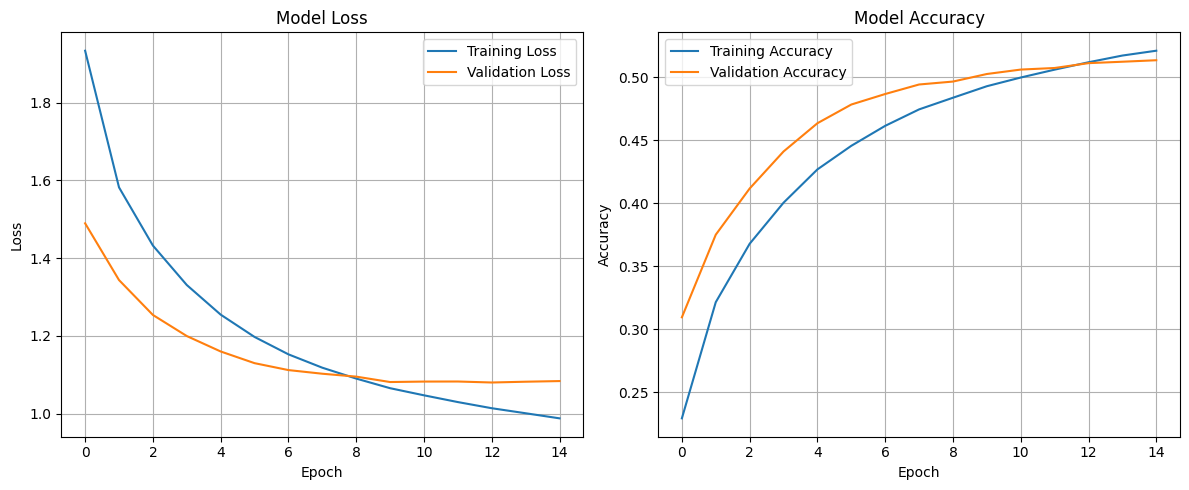

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
import random
import numpy as np

eng_vocab = english_tokenizer.get_vocabulary()
eng_index_lookup = dict(zip(range(len(eng_vocab)), eng_vocab))

def clean_translation(text):
    return text.replace("[start]", "").replace("[end]", "").strip()

def generate_translation(input_sentence):
    tokenized_input_sentence = finnish_tokenizer([input_sentence])
    decoded_sentence = "[start]"

    for i in range(sequence_length):
        tokenized_target_sentence = english_tokenizer([decoded_sentence])
        tokenized_target_sentence = tokenized_target_sentence[:, :-1]

        inputs = [tokenized_input_sentence, tokenized_target_sentence]
        next_token_predictions = transformer2.predict(inputs, verbose=0)

        sampled_token_index = np.argmax(next_token_predictions[0, i, :])
        sampled_token = eng_index_lookup[sampled_token_index]

        decoded_sentence += " " + sampled_token

        if sampled_token == "[end]":
            break

    return clean_translation(decoded_sentence)


In [23]:
for finnish, english in random.sample(test_pairs, k=min(5, len(test_pairs))):
    print("-")
    print("Finnish input:     ", finnish)
    print("Reference English: ", clean_translation(english))
    print("Model translation:", generate_translation(finnish))

-
Finnish input:      totta tosiaan!
Reference English:  indeed!
Model translation: i really mean
-
Finnish input:      tom oli varma, että saisi potkut.
Reference English:  tom was certain that he was going to be fired.
Model translation: tom was sure to be fired
-
Finnish input:      olet heikko.
Reference English:  you're weak.
Model translation: youre weak
-
Finnish input:      osaisinpa mä hiihtää noin.
Reference English:  i wish i could ski like that.
Model translation: i wish i could you
-
Finnish input:      toimistoni on toisessa kerroksessa.
Reference English:  my office is on the second floor.
Model translation: my office is in the other in the other floor
